**Breve descripción:**
*   **Objetivo**: predecir qué clientes tienen mayor probabilidad de aceptar el seguro antirrobos.
*   **Contexto:** resumen del producto (coberturas S/50 billetera, S/350 celular, S/680 laptop).
*   **Variable objetivo:** explicar qué significa FLAG_SS (1 = compró/aceptó el seguro, 0 = no).

In [ ]:
# Importar librerías básicas de análisis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Detección de valores vacios
import missingno as msno # !pip install missingno

# Librerías de modelado y métricas
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

from imblearn.over_sampling import SMOTE

## **Carga y revisión inicial de datos**

In [ ]:
# Cargar el dataset de seguros antirrobos
df = pd.read_csv('DS_Seguro_Antirobos.csv',sep=';')
df.head(10)

,Mto_TC,MARCA,Nombre_territorio,FLAG_LIMA_PROVINCIA,REGION,SUELDO_ESTIMADO,EDAD,SEXO,ANTIGUEDAD_MES,SEGMENTO,FLAG_SS,FLAG_UNICEF
0,5000,Visa,T.CENTRO,0.0,SIERRA CENTRAL,1000.000,24.0,F,28.0,CLASICO,NaN,NaN
1,750,Visa,T.SURCO LA MOLINA,1.0,LIMA MODERNA,2309.875,30.0,F,146.0,CLASICO,NaN,NaN
2,12000,Visa,T.CENTRO,0.0,CENTRO,6541.000,39.0,M,24.0,CLASICO,NaN,NaN
3,2200,Visa,T.LIMA RESIDENCIAL,0.0,NORTE,2196.330,28.0,M,10.0,BAJO VALOR,NaN,NaN
4,5000,Visa,T.CENTRO,1.0,LIMA ESTE,578.000,41.0,M,NaN,NaN,NaN,NaN
5,2400,Visa,T.CENTRO,0.0,CENTRO,899.000,28.0,M,76.0,CLASICO,NaN,NaN
6,6500,Visa,T.CENTRO,0.0,CENTRO,918.500,30.0,M,36.0,CLASICO,NaN,NaN
7,14000,Visa,T.CENTRO,0.0,CENTRO,2907.875,31.0,M,NaN,NaN,NaN,NaN
8,32500,Visa,T.NORTE,0.0,NORTE,7223.440,41.0,F,100.0,CLASICO,NaN,NaN
9,1600,Visa,T.NORTE SUR CHICO,0.0,NORTE,1651.330,48.0,M,133.0,CLASICO,NaN,NaN


In [ ]:
# Dimensiones y tipos de datos
print(df.shape)

(28313, 12)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28313 entries, 0 to 28312
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Mto_TC               28313 non-null  int64  
 1   MARCA                28313 non-null  object 
 2   Nombre_territorio    28313 non-null  object 
 3   FLAG_LIMA_PROVINCIA  27973 non-null  float64
 4   REGION               27973 non-null  object 
 5   SUELDO_ESTIMADO      27593 non-null  float64
 6   EDAD                 27889 non-null  float64
 7   SEXO                 27995 non-null  object 
 8   ANTIGUEDAD_MES       27050 non-null  float64
 9   SEGMENTO             27012 non-null  object 
 10  FLAG_SS              748 non-null    float64
 11  FLAG_UNICEF          123 non-null    float64
dtypes: float64(6), int64(1), object(5)
memory usage: 2.6+ MB


In [ ]:
# Estadísticos descriptivos básicos para variables numéricas
df.describe()

,Mto_TC,FLAG_LIMA_PROVINCIA,SUELDO_ESTIMADO,EDAD,ANTIGUEDAD_MES,FLAG_SS,FLAG_UNICEF
count,28313.000000,27973.000000,27593.000000,27889.000000,27050.000000,748.0,123.0
mean,7865.344718,0.562650,2579.748988,38.245115,81.424104,1.0,1.0
std,10893.489649,0.496068,6069.157465,11.272871,77.243892,0.0,0.0
min,0.000000,0.000000,1.000000,18.000000,1.000000,1.0,1.0
25%,1700.000000,0.000000,1178.000000,29.000000,16.000000,1.0,1.0
50%,5100.000000,1.000000,1748.000000,36.000000,58.000000,1.0,1.0
75%,9500.000000,1.000000,2761.500000,45.000000,120.000000,1.0,1.0
max,169455.000000,1.000000,520650.000000,84.000000,455.000000,1.0,1.0


## **Entendimiento de datos**

**Hallazgos Clave**
1.   FLAG_SS solo tiene 748 valores no nulos de 28,313 filas.
2.   En el descriptivo, FLAG_SS tiene min = max = mean = 1, o sea que todos los no nulos son 1. Al re-etiquetar los NaN como 0 se tendrá un dataset muy desbalanceado.
3.   FLAG_UNICEF solo tiene 123 valores no nulos, y el descriptivo muestra todo 1 (min = max = mean = 1). Es una variable binaria extremadamente rara (~0.4% positivos), que puede aportar algo de señal, pero con riesgo de ser ruidosa o poco útil.
4.   Los montos económicos (Mto_TC y SUELDO_ESTIMADO) tienen outliers fuertes y cola derecha.
5.   Los montos económicos (Mto_TC y SUELDO_ESTIMADO) tienen outliers fuertes y cola derecha.
6.   Estructura geográfica y nulos moderados en varias columnas.

**Variable Objetivo**

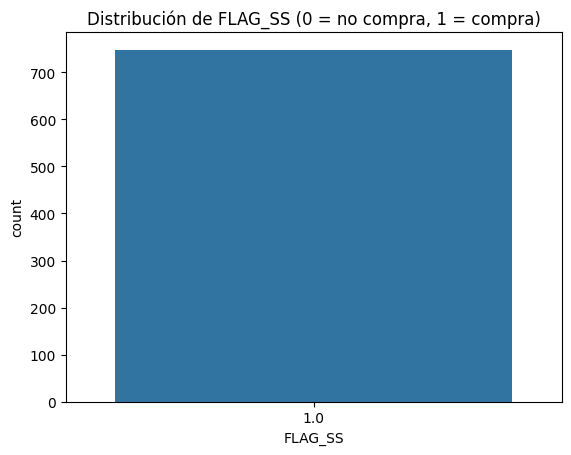

In [ ]:
# Distribución de la variable objetivo FLAG_SS
df['FLAG_SS'].value_counts(dropna=False)
df['FLAG_SS'].value_counts(normalize=True) * 100

sns.countplot(data=df, x='FLAG_SS')
plt.title('Distribución de FLAG_SS (0 = no compra, 1 = compra)')
plt.show()

**Variables numéricas**

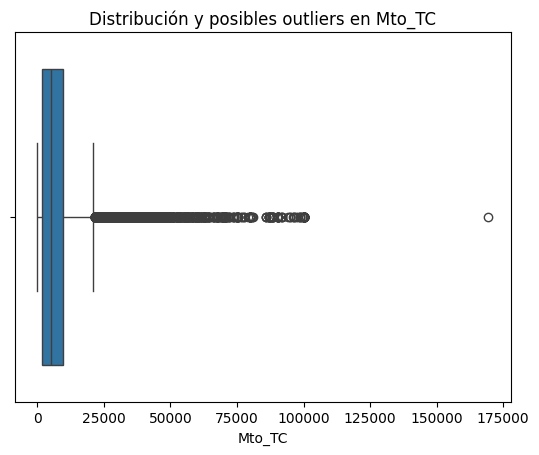

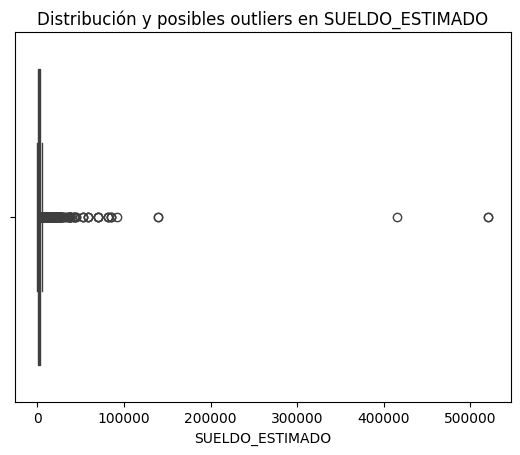

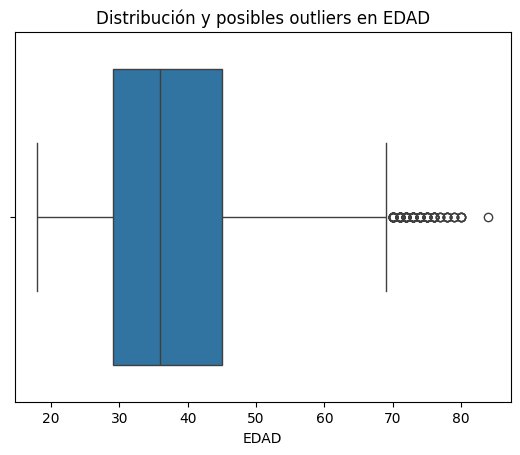

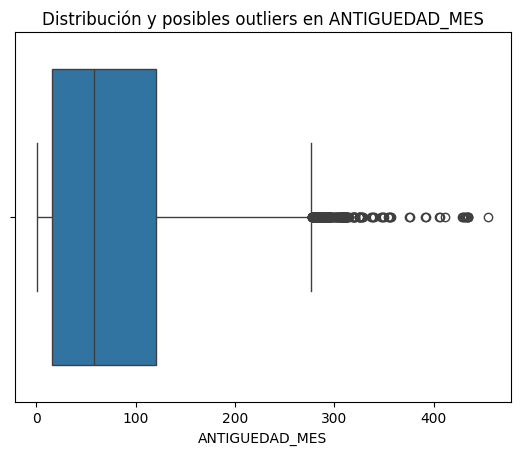

In [ ]:
# reviso distribuciones y posibles outliers con boxplots
numeric_cols = ['Mto_TC', 'SUELDO_ESTIMADO', 'EDAD', 'ANTIGUEDAD_MES']

df[numeric_cols].describe()

for col in numeric_cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f'Distribución y posibles outliers en {col}')
    plt.show()

**Variables categóricas**

In [ ]:
# reviso frecuencia de categorías, identifico categorías raras o muy poco frecuentes
cat_cols = ['MARCA', 'Nombre_territorio', 'FLAG_LIMA_PROVINCIA', 'REGION', 'SEXO', 'SEGMENTO']

for col in cat_cols:
    print(f'\n=== {col} ===')
    print(df[col].value_counts(dropna=False).head(10))


=== MARCA ===
MARCA
Visa          28149
MasterCard      164
Name: count, dtype: int64

=== Nombre_territorio ===
Nombre_territorio
T.CENTROS MASIVOS       6584
T.CENTRO                2508
T.SURCO LA MOLINA       1995
DIR.RED MASIVA          1965
T.LINCE                 1948
T.LIMA RESIDENCIAL      1841
T.SUR                   1794
T.NOR ORIENTE           1757
T.MIRAFLORES S.BORJA    1540
T.CALLAO SAN MIGUEL     1288
Name: count, dtype: int64

=== FLAG_LIMA_PROVINCIA ===
FLAG_LIMA_PROVINCIA
1.0    15739
0.0    12234
NaN      340
Name: count, dtype: int64

=== REGION ===
REGION
LIMA MODERNA    4545
NORTE           3806
SUR             3226
LIMA NORTE      2771
CENTRO          2632
LIMA ESTE       2609
LIMA CENTRO     2305
LIMA SUR        1813
ORIENTE         1624
CALLAO          1069
Name: count, dtype: int64

=== SEXO ===
SEXO
M      16397
F      11598
NaN      318
Name: count, dtype: int64

=== SEGMENTO ===
SEGMENTO
CLASICO          18719
BAJO VALOR        5572
VIP               1513

**Relación con la variable objetivo**

In [ ]:
# calculo % de clientes que compran seguro por cada región
region_churn = df.groupby('REGION')['FLAG_SS'].mean().sort_values(ascending=False)
region_churn

,FLAG_SS
REGION,
CALLAO,1.0
CENTRO,1.0
LIMA CENTRO,1.0
LIMA ESTE,1.0
LIMA MODERNA,1.0
LIMA NORTE,1.0
LIMA PROVINCIA,1.0
LIMA SUR,1.0
NORTE,1.0


**Hallazgos Clave**
1. **Desbalance de la variable objetivo** - Solo hay 748 registros con FLAG_SS = 1 sobre 28,313 clientes (~2.6%). En el resto el flag está vacío, por lo que se interpretará como “no compra”. Es un problema de etiqueta muy escasa y fuertemente desbalanceada.

2. **Cobertura geográfica del seguro** - Los pocos casos con FLAG_SS = 1 aparecen en todas las regiones (Callao, Lima Centro, Norte, Sur, Sierra, Oriente, etc.), sin una región claramente excluida. Es decir, la oferta del seguro se ha vendido en todo el mapa comercial.

3. **Monto de TC y sueldo con fuerte dispersión y outliers** - Mto_TC y SUELDO_ESTIMADO muestran colas derechas muy largas y valores extremos (líneas de crédito y sueldos excepcionalmente altos). Esto confirma que serán variables relevantes, pero requerirán capping por percentil para que unos pocos clientes no dominen el modelo.

4. **MARCA y territorios poco equilibrados** - Casi todos los clientes tienen tarjeta Visa (más de 28k) y muy pocos MasterCard (~160), por lo que MARCA aportará poca capacidad de segmentación. En cambio, los territorios (Nombre_territorio) están más repartidos y algunos canales masivos concentran gran parte de la base.

5. **Perfil del cliente: edad y antigüedad variadas, con colas largas** -
La edad típica está entre 30 y 45 años, pero hay clientes hasta de 80+, y la ANTIGÜEDAD_MES va desde 1 mes hasta más de 450 meses. Hay tanto clientes muy nuevos como muy antiguos, con muchos outliers hacia antigüedades altas, lo que sugiere que esta variable puede ayudar a distinguir la probabilidad de compra y también requerirá tratamiento de valores extremos.

## **Tratamiento de datos**

In [ ]:
# verifico cuántos valores nulos hay por columna
df.isna().sum() / 28313

,0
Mto_TC,0.000000
MARCA,0.000000
Nombre_territorio,0.000000
FLAG_LIMA_PROVINCIA,0.012009
REGION,0.012009
SUELDO_ESTIMADO,0.025430
EDAD,0.014975
SEXO,0.011232
ANTIGUEDAD_MES,0.044608
SEGMENTO,0.045951


<Axes: >

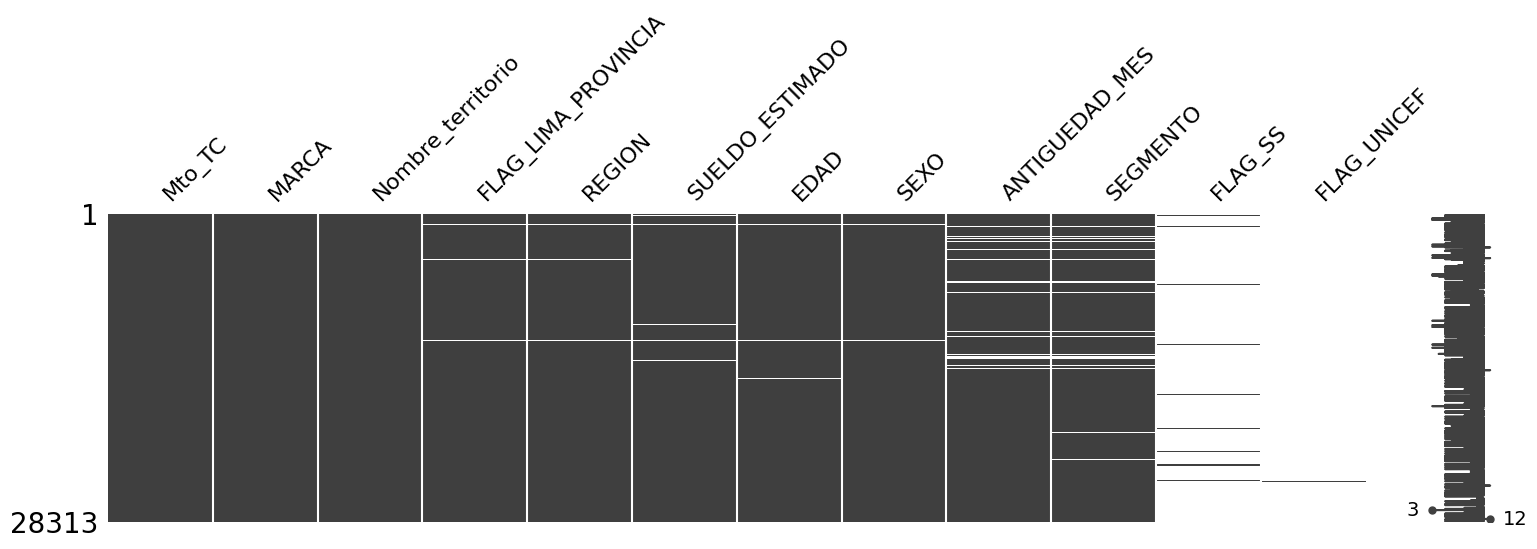

In [ ]:
# ver la correlacion o relación de los vacios
msno.matrix(df, figsize=(18, 4))

**Imputación de nulos**

In [ ]:
# definimos imputadores, pero la imputación se aplicará dentro del pipeline.

from sklearn.impute import SimpleImputer

# imputación numérica: mediana (robusta a outliers)
numeric_imputer = SimpleImputer(strategy='median')

# imputación categórica: moda (valor más frecuente)
categorical_imputer = SimpleImputer(strategy='most_frequent')


In [ ]:
# topéo los valores extremos para reducir su impacto en el modelo y dejo los NaN como NaN (se imputarán después).

numeric_cols = ['Mto_TC', 'SUELDO_ESTIMADO', 'EDAD', 'ANTIGUEDAD_MES']

for col in numeric_cols:
    p99 = df[col].dropna().quantile(0.99)
    df[col] = np.where(df[col] > p99, p99, df[col])

df[numeric_cols].describe()

,Mto_TC,SUELDO_ESTIMADO,EDAD,ANTIGUEDAD_MES
count,28313.000000,27593.000000,27889.000000,27050.000000
mean,7695.848197,2425.144158,38.202947,81.089464
std,9799.971092,2197.388607,11.155118,76.249127
min,0.000000,1.000000,18.000000,1.000000
25%,1700.000000,1178.000000,29.000000,16.000000
50%,5100.000000,1748.000000,36.000000,58.000000
75%,9500.000000,2761.500000,45.000000,120.000000
max,60500.000000,13666.960000,66.000000,276.000000


**Definir listas numéricas/categóricas y el ColumnTransformer**

In [ ]:
# preparación de listas de columnas numéricas y categóricas finales
numeric_cols = ['Mto_TC', 'SUELDO_ESTIMADO', 'EDAD', 'ANTIGUEDAD_MES']
cat_cols = ['MARCA', 'Nombre_territorio', 'FLAG_LIMA_PROVINCIA',
            'REGION', 'SEXO', 'SEGMENTO', 'FLAG_UNICEF']

from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [ ]:
# transformador numérico: imputar mediana
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

In [ ]:
# transformador categórico: imputar moda + One-Hot
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, cat_cols)
    ]
)

**Imputación en DataFrame**

In [ ]:
numeric_cols = ['Mto_TC', 'SUELDO_ESTIMADO', 'EDAD', 'ANTIGUEDAD_MES']
cat_cols = ['MARCA', 'Nombre_territorio', 'FLAG_LIMA_PROVINCIA',
            'REGION', 'SEXO', 'SEGMENTO', 'FLAG_UNICEF']

# imputación numérica con la mediana
for col in numeric_cols:
    mediana = df[col].median()
    df[col] = df[col].fillna(mediana)

# imputación categórica con la moda (valor más frecuente)
for col in ['FLAG_LIMA_PROVINCIA', 'REGION', 'SEXO', 'SEGMENTO']:
    moda = df[col].mode()[0]
    df[col] = df[col].fillna(moda)

In [ ]:
# confirmar que ya no hay NaN en las columnas numéricas y categóricas clave
df[numeric_cols + ['FLAG_LIMA_PROVINCIA', 'REGION', 'SEXO', 'SEGMENTO']].isnull().sum()

,0
Mto_TC,0
SUELDO_ESTIMADO,0
EDAD,0
ANTIGUEDAD_MES,0
FLAG_LIMA_PROVINCIA,0
REGION,0
SEXO,0
SEGMENTO,0


**Conversión de FLAG_SS a Binario (0/1)**

In [ ]:
df['FLAG_SS'].value_counts(dropna=False)
df['FLAG_SS'].isnull().sum()

np.int64(0)

In [ ]:
# asegurar que la variable objetivo no tiene NaN
df['FLAG_SS'] = df['FLAG_SS'].fillna(0).astype(int)

# confirmar que ya no hay NaN en y
print(df['FLAG_SS'].value_counts(dropna=False))
print("NaN en FLAG_SS:", df['FLAG_SS'].isnull().sum())

FLAG_SS
0    27565
1      748
Name: count, dtype: int64
NaN en FLAG_SS: 0


**Limpieza de FLAG_UNICEF**

In [ ]:
df['FLAG_UNICEF'].value_counts(dropna=False)

,count
FLAG_UNICEF,
NaN,28190
1.0,123


In [ ]:
# convertir NaN a 0 y tipificar como entero
df['FLAG_UNICEF'] = df['FLAG_UNICEF'].fillna(0).astype(int)

In [ ]:
# confirmar que ya no hay NaN
print(df['FLAG_UNICEF'].value_counts(dropna=False))
print("NaN en FLAG_UNICEF:", df['FLAG_UNICEF'].isnull().sum())

FLAG_UNICEF
0    28190
1      123
Name: count, dtype: int64
NaN en FLAG_UNICEF: 0


**Split train/test**

In [ ]:
numeric_cols = ['Mto_TC', 'SUELDO_ESTIMADO', 'EDAD', 'ANTIGUEDAD_MES']
cat_cols = ['MARCA', 'Nombre_territorio', 'FLAG_LIMA_PROVINCIA',
            'REGION', 'SEXO', 'SEGMENTO', 'FLAG_UNICEF']

X = df[numeric_cols + cat_cols]
y = df['FLAG_SS']

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

**Codificar variables categóricas con get_dummies**

In [ ]:
# convierto las categóricas a variables numéricas (dummies)

X_train_enc = pd.get_dummies(X_train, drop_first=True)
X_test_enc = pd.get_dummies(X_test, drop_first=True)

# alinear columnas entre train y test
X_test_enc = X_test_enc.reindex(columns=X_train_enc.columns, fill_value=0)

print("Shape X_train_enc:", X_train_enc.shape)
print("Shape X_test_enc :", X_test_enc.shape)

Shape X_train_enc: (19819, 41)
Shape X_test_enc : (8494, 41)


**SelectKBest**

In [ ]:
# Chequeo rápido de NaN en X codificado
X_train_enc.isnull().sum().sum()

np.int64(0)

In [ ]:
X_train_enc.isnull().sum().sort_values(ascending=False).head(20)

,0
Mto_TC,0
SUELDO_ESTIMADO,0
EDAD,0
ANTIGUEDAD_MES,0
FLAG_LIMA_PROVINCIA,0
FLAG_UNICEF,0
MARCA_Visa,0
Nombre_territorio_S.C.RECURSOS HUMANOS,0
Nombre_territorio_T.BANCA PREMIUM,0
Nombre_territorio_T.CALLAO SAN MIGUEL,0


In [ ]:
from sklearn.feature_selection import SelectKBest, f_classif

k = 15
feature_selector = SelectKBest(score_func=f_classif, k=k)

X_train_kbest = feature_selector.fit_transform(X_train_enc, y_train)
X_test_kbest = feature_selector.transform(X_test_enc)

print("Shape X_train_kbest:", X_train_kbest.shape)
print("Shape X_test_kbest :", X_test_kbest.shape)

Shape X_train_kbest: (19819, 15)
Shape X_test_kbest : (8494, 15)


**K-Variables más Importantes**

In [ ]:
# tabla de features seleccionadas y sus scores
import pandas as pd

mask = feature_selector.get_support()
selected_features = X_train_enc.columns[mask]
scores = feature_selector.scores_[mask]

feat_importance = pd.DataFrame({
    'feature': selected_features,
    'score': scores
}).sort_values(by='score', ascending=False)

feat_importance.head(10)

,feature,score
10,REGION_ORIENTE,79.234090
0,Mto_TC,77.345076
3,ANTIGUEDAD_MES,59.734033
12,SEGMENTO_CLASICO,41.165045
11,SEXO_M,36.463100
1,SUELDO_ESTIMADO,35.241927
2,EDAD,33.285571
7,Nombre_territorio_T.NOR ORIENTE,31.981968
14,SEGMENTO_VIP,30.609089
13,SEGMENTO_Micro empresa,23.719987


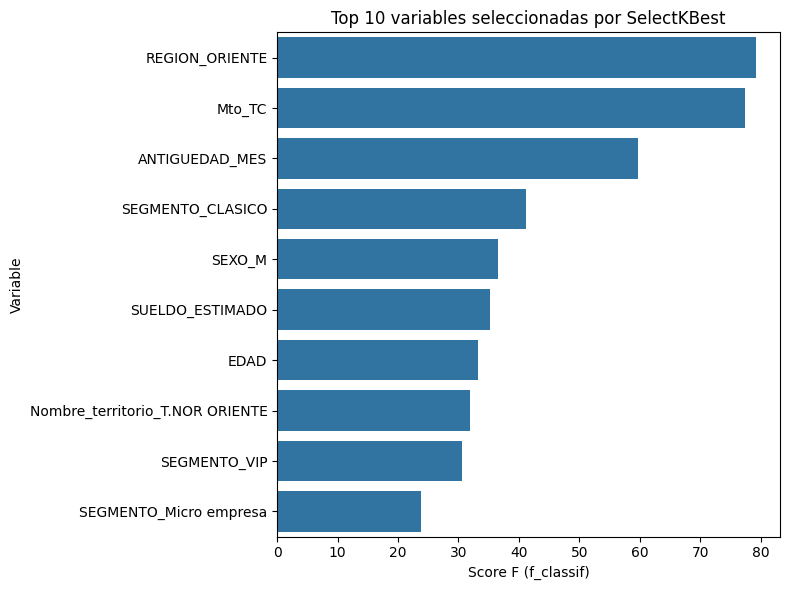

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.barplot(
    data=feat_importance.head(10),
    x='score',
    y='feature'
)
plt.title('Top 10 variables seleccionadas por SelectKBest')
plt.xlabel('Score F (f_classif)')
plt.ylabel('Variable')
plt.tight_layout()
plt.show()

## **Balanceo de Datos**

Distribución original y_train:
FLAG_SS
0    19295
1      524
Name: count, dtype: int64

Porcentaje:
FLAG_SS
0    97.356072
1     2.643928
Name: proportion, dtype: float64


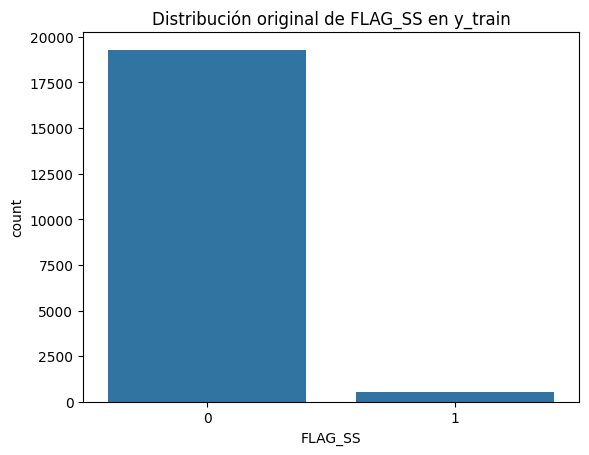

In [ ]:
# distribución original de la variable objetivo en train
print("Distribución original y_train:")
print(y_train.value_counts())
print("\nPorcentaje:")
print(y_train.value_counts(normalize=True) * 100)

sns.countplot(x=y_train)
plt.title('Distribución original de FLAG_SS en y_train')
plt.show()

Distribución balanceada y_train_res:
FLAG_SS
0    19295
1    19295
Name: count, dtype: int64

Porcentaje:
FLAG_SS
0    50.0
1    50.0
Name: proportion, dtype: float64


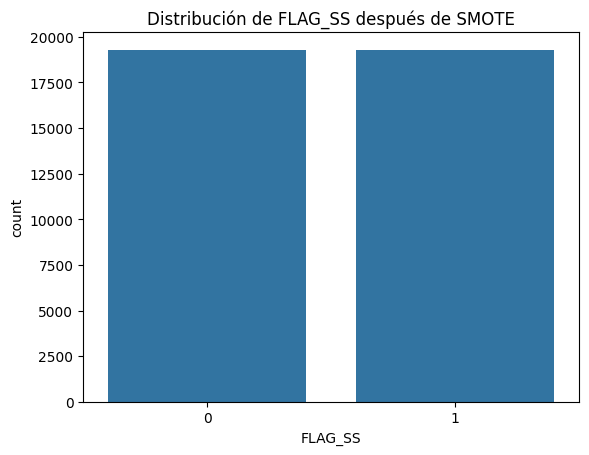

In [ ]:
from imblearn.over_sampling import SMOTE

# aplicar SMOTE sobre X_train_kbest
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train_kbest, y_train)

print("Distribución balanceada y_train_res:")
print(y_train_res.value_counts())
print("\nPorcentaje:")
print(y_train_res.value_counts(normalize=True) * 100)

sns.countplot(x=y_train_res)
plt.title('Distribución de FLAG_SS después de SMOTE')
plt.show()

## **Modelado**

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [ ]:
def entrenar_y_evaluar(nombre_modelo, modelo_base):
    # entrenamos con el train balanceado
    modelo_base.fit(X_train_res, y_train_res)

    # predecimos sobre el test (no balanceado), con las mismas k features
    y_pred = modelo_base.predict(X_test_kbest)
    y_proba = modelo_base.predict_proba(X_test_kbest)[:, 1]

    print(f'\n=== Resultados: {nombre_modelo} ===')
    print('Accuracy :', accuracy_score(y_test, y_pred))
    print('Precision:', precision_score(y_test, y_pred))
    print('Recall   :', recall_score(y_test, y_pred))
    print('F1       :', f1_score(y_test, y_pred))
    print('AUC      :', roc_auc_score(y_test, y_proba))

    print('\nMatriz de confusión:')
    print(confusion_matrix(y_test, y_pred))

    print('\nReporte de clasificación:')
    print(classification_report(y_test, y_pred))

    return modelo_base

In [ ]:
# Árbol de decisión
dt_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=5
)
modelo_dt = entrenar_y_evaluar('Decision Tree', dt_model)


=== Resultados: Decision Tree ===
Accuracy : 0.9421944902283965
Precision: 0.11078717201166181
Recall   : 0.16964285714285715
F1       : 0.13403880070546736
AUC      : 0.6760907000345483

Matriz de confusión:
[[7965  305]
 [ 186   38]]

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.98      0.96      0.97      8270
           1       0.11      0.17      0.13       224

    accuracy                           0.94      8494
   macro avg       0.54      0.57      0.55      8494
weighted avg       0.95      0.94      0.95      8494



In [ ]:
# Random Forest
rf_model = RandomForestClassifier(
    random_state=42,
    n_estimators=200,
    max_depth=None,
    n_jobs=-1
)
modelo_rf = entrenar_y_evaluar('Random Forest', rf_model)


=== Resultados: Random Forest ===
Accuracy : 0.9821050153049211
Precision: 0.8913043478260869
Recall   : 0.36607142857142855
F1       : 0.5189873417721519
AUC      : 0.8213513776127138

Matriz de confusión:
[[8260   10]
 [ 142   82]]

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      8270
           1       0.89      0.37      0.52       224

    accuracy                           0.98      8494
   macro avg       0.94      0.68      0.75      8494
weighted avg       0.98      0.98      0.98      8494



In [ ]:
# XGBoost
xgb_model = xgb.XGBClassifier(
    random_state=42,
    n_estimators=200,
    learning_rate=0.1,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    n_jobs=-1
)
modelo_xgb = entrenar_y_evaluar('XGBoost', xgb_model)


=== Resultados: XGBoost ===
Accuracy : 0.9672710148340005
Precision: 0.17073170731707318
Recall   : 0.0625
F1       : 0.0915032679738562
AUC      : 0.7389415810157195

Matriz de confusión:
[[8202   68]
 [ 210   14]]

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.98      0.99      0.98      8270
           1       0.17      0.06      0.09       224

    accuracy                           0.97      8494
   macro avg       0.57      0.53      0.54      8494
weighted avg       0.95      0.97      0.96      8494



In [ ]:
import pandas as pd

resultados = pd.DataFrame({
    'modelo':   ['Decision Tree', 'Random Forest', 'XGBoost'],
    'accuracy': [0.9422, 0.9821, 0.9673],
    'precision':[0.1108, 0.8913, 0.1707],
    'recall':   [0.1696, 0.3661, 0.0625],
    'f1':       [0.1340, 0.5190, 0.0915],
    'auc':      [0.6761, 0.8214, 0.7389]
})

resultados

,modelo,accuracy,precision,recall,f1,auc
0,Decision Tree,0.9422,0.1108,0.1696,0.1340,0.6761
1,Random Forest,0.9821,0.8913,0.3661,0.5190,0.8214
2,XGBoost,0.9673,0.1707,0.0625,0.0915,0.7389


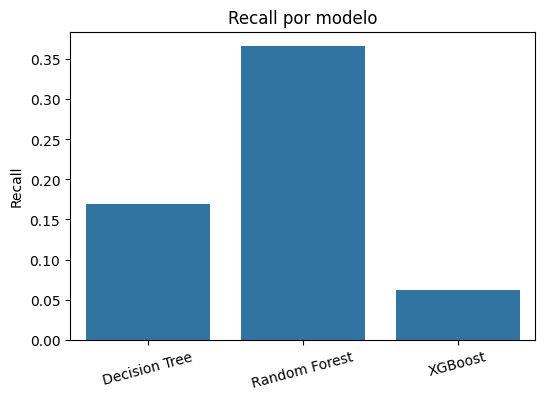

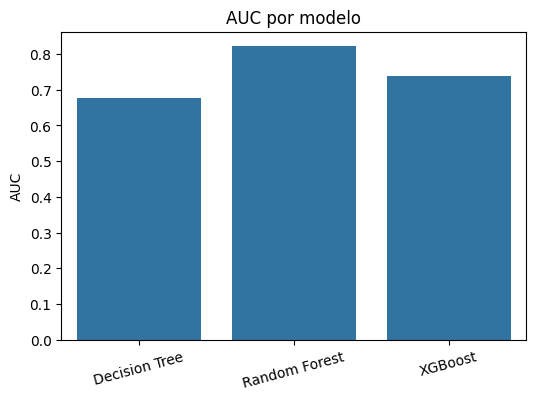

In [ ]:
plt.figure(figsize=(6,4))
sns.barplot(data=resultados, x='modelo', y='recall')
plt.title('Recall por modelo')
plt.ylabel('Recall')
plt.xlabel('')
plt.xticks(rotation=15)
plt.show()

plt.figure(figsize=(6,4))
sns.barplot(data=resultados, x='modelo', y='auc')
plt.title('AUC por modelo')
plt.ylabel('AUC')
plt.xlabel('')
plt.xticks(rotation=15)
plt.show()

## **Evaluación**

### Métrica principal

El objetivo del modelo es priorizar a los clientes con mayor probabilidad de aceptar el **seguro antirrobos**.  
En este contexto:

- La clase positiva (`FLAG_SS = 1`) es minoritaria.
- El error más costoso es **no identificar a un cliente que sí compraría** (venta perdida).
- El costo de contactar a alguien que finalmente no compra es relativamente bajo.

Por esto, la métrica principal es:

- **Recall (sensibilidad) de la clase 1**: porcentaje de compradores reales que el modelo logra detectar.

Como métrica complementaria usamos:

- **AUC-ROC**: mide la capacidad global del modelo para separar clientes con alta vs. baja propensión, independientemente del umbral.

### Modelo seleccionado

- **Modelo elegido:** **Random Forest**
- **Motivo principal:** ofrece el mejor equilibrio entre:
  - **Capturar oportunidades de venta** (Recall ≈ 36% de la clase 1),
  - **Calidad de ranking** (AUC ≈ 0.82),
  - y **contactos eficientes** (Precision ≈ 0.89: casi 9 de cada 10 “predichos como compradores” realmente lo son).

Este modelo es el más adecuado para priorizar clientes en campañas de oferta del seguro antirrobos.

## **Despliegue**

### Principales insights del modelo

El Random Forest, combinado con la selección de variables, destaca las siguientes **características clave**:

- Hay una **fuerte señal geográfica** (REGION_ORIENTE y T.NOR ORIENTE): ciertas zonas responden mejor al seguro.
- La **capacidad económica y la relación con la entidad** importan:
  - Clientes con **mayor límite de TC**, **mayor sueldo estimado** y **más antigüedad** tienden a aceptar más el producto.
- Los **segmentos CLÁSICO, VIP y Micro empresa** concentran buena parte de la propensión.
- `SEXO_M` influye en el modelo, pero por riesgo de sesgos se debe usar solo dentro del score, **no como filtro directo de negocio**.

### Uso propuesto del modelo en campañas

**Idea principal:** usar el Random Forest como **motor de “score de propensión”** para ordenar clientes según la probabilidad de aceptar el seguro.

Ejemplo de estrategia:

- Calcular un **score de 0 a 1** para cada cliente.
- Definir umbrales de acción:
  - **Score ≥ 0.70** = clientes de alta propensión:
    - Contacto intensivo: llamada + SMS + email.
    - Enfoque especial en REGION_ORIENTE, T.NOR ORIENTE, segmentos CLÁSICO/VIP y clientes con alta antigüedad.
  - **0.50 ≤ score < 0.70** = propensión media:
    - Contacto de bajo costo: SMS o email automatizado.
  - **Score < 0.50** = baja prioridad en la campaña principal:
    - Pueden entrar en acciones masivas o se dejan para futuras campañas.

De esta manera, se **optimiza el presupuesto comercial**, concentrando esfuerzos donde el modelo ve más probabilidad de conversión.

### Próximos pasos recomendados

1. **Campaña piloto**
   - Ejecutar una campaña controlada usando el score del modelo (por ejemplo, top 20% de clientes).
   - Medir tasas de conversión y comparar contra una campaña masiva tradicional.

2. **Ajustar umbrales según capacidad comercial**
   - Ajustar el punto de corte del score en función del número de clientes que el equipo puede contactar cada mes.

3. **Enriquecer el modelo**
   - Incorporar nuevas variables:
     - Historial de siniestros o robos.
     - Comportamiento de uso de la tarjeta.
     - Respuesta a campañas anteriores.
   - Esto podría mejorar el Recall y el AUC.

4. **Monitoreo y reentrenamiento**
   - Monitorear periódicamente Recall, AUC y conversión real.
   - Reentrenar el modelo con datos más recientes (por ejemplo, cada 6–12 meses) para mantener su desempeño.

5. **Revisión de riesgos y sesgos**
   - Verificar que las decisiones de negocio se basen en el **score global** y no solo en variables sensibles individuales.
   - En caso necesario, apoyar la explicación del modelo con técnicas de interpretabilidad (por ejemplo, SHAP) para casos críticos.

Con esto, el modelo de Random Forest queda listo no solo desde el punto de vista técnico,  
sino también con una **hoja de ruta clara para ser usado en la estrategia comercial del seguro antirrobos**.